In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("当前使用设备：", device)

A = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
], device=device)

B = torch.tensor([
    [5.0, 6.0],
    [7.0, 8.0]
], device=device)

print("A 的形状：", A.shape)
print("A 所在设备：", A.device)

print("\n逐元素乘法 A * B：")
print(A * B)

print("\n矩阵乘法 A @ B：")
print(A @ B)


当前使用设备： cuda
A 的形状： torch.Size([2, 2])
A 所在设备： cuda:0

逐元素乘法 A * B：
tensor([[ 5., 12.],
        [21., 32.]], device='cuda:0')

矩阵乘法 A @ B：
tensor([[19., 22.],
        [43., 50.]], device='cuda:0')


In [2]:
# 创建包含 0～11 的一维张量
x = torch.arange(12, dtype=torch.float32, device=device)

print("原始张量：")
print(x)
print("原始形状：", x.shape)

# 将一维张量变成 3 行 4 列
X = x.reshape(3, 4)

print("\n变形后的张量：")
print(X)
print("变形后的形状：", X.shape)

print("\n第 2 行：")
print(X[1])

print("\n第 1 列：")
print(X[:, 0])

print("\n转置后的矩阵：")
print(X.T)

# GPU 张量转成 NumPy 数组时，要先放回 CPU
X_numpy = X.cpu().numpy()

print("\n转换后的类型：", type(X_numpy))
print(X_numpy)

原始张量：
tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.],
       device='cuda:0')
原始形状： torch.Size([12])

变形后的张量：
tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]], device='cuda:0')
变形后的形状： torch.Size([3, 4])

第 2 行：
tensor([4., 5., 6., 7.], device='cuda:0')

第 1 列：
tensor([0., 4., 8.], device='cuda:0')

转置后的矩阵：
tensor([[ 0.,  4.,  8.],
        [ 1.,  5.,  9.],
        [ 2.,  6., 10.],
        [ 3.,  7., 11.]], device='cuda:0')

转换后的类型： <class 'numpy.ndarray'>
[[ 0.  1.  2.  3.]
 [ 4.  5.  6.  7.]
 [ 8.  9. 10. 11.]]


In [3]:
# 创建一个需要计算梯度的变量
x = torch.tensor(2.0, device=device, requires_grad=True)

# 定义函数 y = x² + 3x + 1
y = x**2 + 3*x + 1

print("x =", x.item())
print("y =", y.item())

# 自动计算 dy/dx
y.backward()

print("PyTorch 计算的梯度：", x.grad.item())
print("理论梯度：", 2 * x.item() + 3)

x = 2.0
y = 11.0
PyTorch 计算的梯度： 7.0
理论梯度： 7.0


In [4]:
# 初始参数为 0，并要求 PyTorch 跟踪梯度
w = torch.tensor(0.0, device=device, requires_grad=True)

learning_rate = 0.2

for epoch in range(10):
    # 目标是让 w 接近 3
    loss = (w - 3) ** 2

    # 计算损失对 w 的梯度
    loss.backward()

    # 根据梯度更新 w
    with torch.no_grad():
        w -= learning_rate * w.grad

    # 清空本轮梯度
    w.grad.zero_()

    print(
        f"第 {epoch + 1:02d} 轮："
        f"w = {w.item():.6f}，"
        f"loss = {loss.item():.6f}"
    )

第 01 轮：w = 1.200000，loss = 9.000000
第 02 轮：w = 1.920000，loss = 3.240000
第 03 轮：w = 2.352000，loss = 1.166400
第 04 轮：w = 2.611200，loss = 0.419904
第 05 轮：w = 2.766720，loss = 0.151165
第 06 轮：w = 2.860032，loss = 0.054420
第 07 轮：w = 2.916019，loss = 0.019591
第 08 轮：w = 2.949611，loss = 0.007053
第 09 轮：w = 2.969767，loss = 0.002539
第 10 轮：w = 2.981860，loss = 0.000914


In [5]:
w = torch.tensor(0.0, device=device, requires_grad=True)
learning_rate = 0.2

for epoch in range(10):
    # 使用更新前的 w 计算损失
    loss_before = (w - 3) ** 2
    loss_before.backward()

    old_w = w.item()
    gradient = w.grad.item()

    # 更新参数，并计算更新后的损失
    with torch.no_grad():
        w -= learning_rate * w.grad
        loss_after = (w - 3) ** 2

    print(
        f"第 {epoch + 1:02d} 轮："
        f"更新前 w={old_w:.6f}，"
        f"梯度={gradient:.6f}，"
        f"更新后 w={w.item():.6f}，"
        f"更新后 loss={loss_after.item():.6f}"
    )

    w.grad.zero_()

第 01 轮：更新前 w=0.000000，梯度=-6.000000，更新后 w=1.200000，更新后 loss=3.240000
第 02 轮：更新前 w=1.200000，梯度=-3.600000，更新后 w=1.920000，更新后 loss=1.166400
第 03 轮：更新前 w=1.920000，梯度=-2.160000，更新后 w=2.352000，更新后 loss=0.419904
第 04 轮：更新前 w=2.352000，梯度=-1.296000，更新后 w=2.611200，更新后 loss=0.151165
第 05 轮：更新前 w=2.611200，梯度=-0.777600，更新后 w=2.766720，更新后 loss=0.054420
第 06 轮：更新前 w=2.766720，梯度=-0.466560，更新后 w=2.860032，更新后 loss=0.019591
第 07 轮：更新前 w=2.860032，梯度=-0.279936，更新后 w=2.916019，更新后 loss=0.007053
第 08 轮：更新前 w=2.916019，梯度=-0.167962，更新后 w=2.949611，更新后 loss=0.002539
第 09 轮：更新前 w=2.949611，梯度=-0.100777，更新后 w=2.969767，更新后 loss=0.000914
第 10 轮：更新前 w=2.969767，梯度=-0.060466，更新后 w=2.981860，更新后 loss=0.000329


In [6]:
import torch.nn as nn

torch.manual_seed(42)

# 训练数据，每一行为一个样本
x_train = torch.tensor(
    [[0.0], [1.0], [2.0], [3.0], [4.0]],
    device=device
)

y_train = torch.tensor(
    [[1.0], [3.0], [5.0], [7.0], [9.0]],
    device=device
)

# 一层线性模型：预测值 = weight × x + bias
model = nn.Linear(in_features=1, out_features=1).to(device)

# 均方误差损失
loss_function = nn.MSELoss()

# 随机梯度下降优化器
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

for epoch in range(501):
    # 前向传播
    y_pred = model(x_train)

    # 计算预测值与真实值之间的误差
    loss = loss_function(y_pred, y_train)

    # 清空上一轮的梯度
    optimizer.zero_grad()

    # 反向传播
    loss.backward()

    # 更新 weight 和 bias
    optimizer.step()

    if epoch % 100 == 0:
        print(f"第 {epoch:03d} 轮，loss = {loss.item():.8f}")

print("\n学习到的 weight：", model.weight.item())
print("学习到的 bias：", model.bias.item())

# 使用训练好的模型预测 x=5
with torch.no_grad():
    test_x = torch.tensor([[5.0]], device=device)
    prediction = model(test_x)

print("当 x=5 时，模型预测 y =", prediction.item())

第 000 轮，loss = 10.02716255
第 100 轮，loss = 0.00004305
第 200 轮，loss = 0.00000010
第 300 轮，loss = 0.00000000
第 400 轮，loss = 0.00000000
第 500 轮，loss = 0.00000000

学习到的 weight： 1.9999991655349731
学习到的 bias： 1.000002145767212
当 x=5 时，模型预测 y = 10.999998092651367


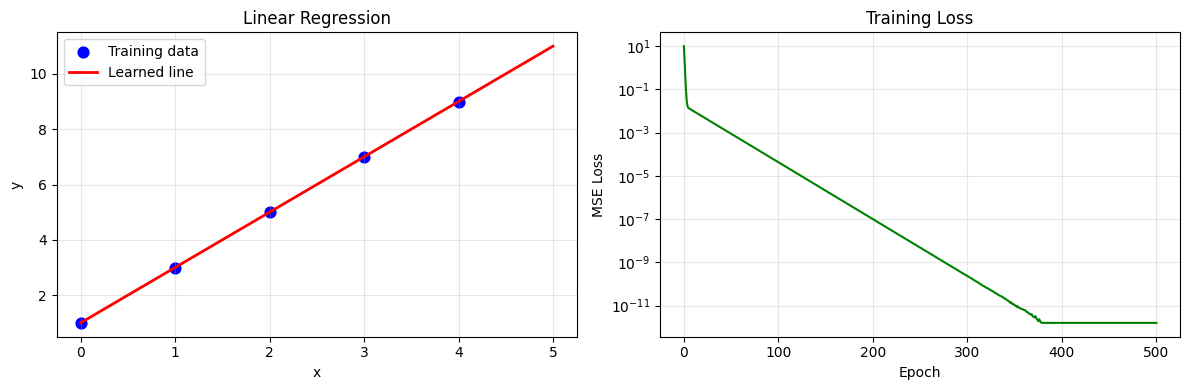

In [7]:
import matplotlib.pyplot as plt
import torch.nn as nn

# 重新创建模型，目的是重新训练并记录每一轮的 loss
torch.manual_seed(42)

plot_model = nn.Linear(1, 1).to(device)
plot_loss_function = nn.MSELoss()
plot_optimizer = torch.optim.SGD(
    plot_model.parameters(),
    lr=0.05
)

# 用于保存每一轮的损失
loss_history = []

for epoch in range(501):
    # 清空旧梯度
    plot_optimizer.zero_grad()

    # 前向传播
    y_pred = plot_model(x_train)

    # 计算损失
    loss = plot_loss_function(y_pred, y_train)

    # 保存当前损失
    loss_history.append(loss.item())

    # 反向传播和参数更新
    loss.backward()
    plot_optimizer.step()

# 生成0～5之间的100个横坐标，用于绘制平滑直线
x_line = torch.linspace(
    0, 5, 100, device=device
).reshape(-1, 1)

# 使用训练后的模型进行预测
with torch.no_grad():
    y_line = plot_model(x_line)

# Matplotlib只能直接处理CPU上的NumPy数组
x_train_np = x_train.cpu().numpy().ravel()
y_train_np = y_train.cpu().numpy().ravel()
x_line_np = x_line.cpu().numpy().ravel()
y_line_np = y_line.cpu().numpy().ravel()

# 创建两个并排的图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：训练数据与模型拟合直线
axes[0].scatter(
    x_train_np,
    y_train_np,
    color="blue",
    s=60,
    label="Training data"
)

axes[0].plot(
    x_line_np,
    y_line_np,
    color="red",
    linewidth=2,
    label="Learned line"
)

axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Linear Regression")
axes[0].legend()
axes[0].grid(alpha=0.3)

# 右图：训练损失曲线
axes[1].plot(loss_history, color="green")
axes[1].set_yscale("log")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title("Training Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()